In [126]:
import pandas as pd

df = pd.read_csv("../../data/sp500_index.csv")
df = df.dropna()
df = df.drop_duplicates()
df.head()

,Date,S&P500
0,2014-12-22,2078.54
1,2014-12-23,2082.17
2,2014-12-24,2081.88
3,2014-12-26,2088.77
4,2014-12-29,2090.57


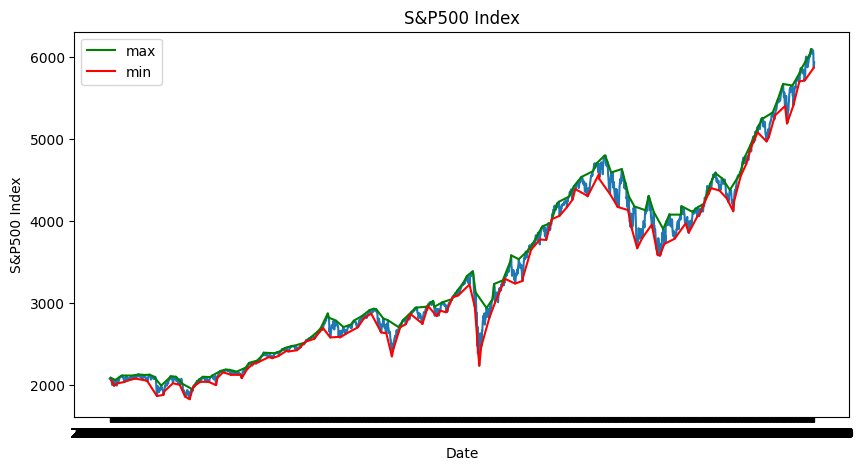

In [ ]:
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

df["Year"] = pd.to_datetime(df["Date"]).dt.year
df["Month"] = pd.to_datetime(df["Date"]).dt.month
X = df.loc[:, ["Date"]]
y = df["S&P500"]

min_per_year = df.groupby("Year")["S&P500"].idxmin()
max_per_year = df.groupby("Year")["S&P500"].idxmax()

min_per_month = df.groupby(["Year", "Month"])["S&P500"].idxmin()
max_per_month = df.groupby(["Year", "Month"])["S&P500"].idxmax()

X_min = pd.DataFrame(df.loc[min_per_month, ["Date"]]).copy()
y_min = df.loc[min_per_month, "S&P500"]

X_max = pd.DataFrame(df.loc[max_per_month, ["Date"]]).copy()
y_max = df.loc[max_per_month, "S&P500"]

X_min["Date ordinal"] = pd.to_datetime(X_min["Date"]).apply(lambda x: x.toordinal())
X_max["Date ordinal"] = pd.to_datetime(X_max["Date"]).apply(lambda x: x.toordinal())

plt.figure(figsize=(10, 5))
plt.plot(X["Date"], y)
plt.plot(
    df.loc[max_per_month, "Date"],
    df.loc[max_per_month, "S&P500"],
    c="green",
    label="max",
)
plt.plot(X_min["Date"], y_min, c="red", label="min")
plt.legend()
plt.title("S&P500 Index")
plt.xlabel("Date")
plt.ylabel("S&P500 Index")
plt.show()

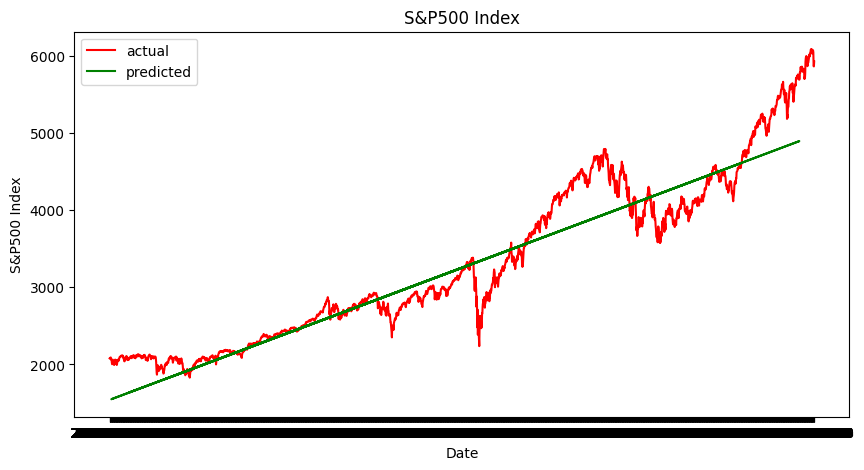

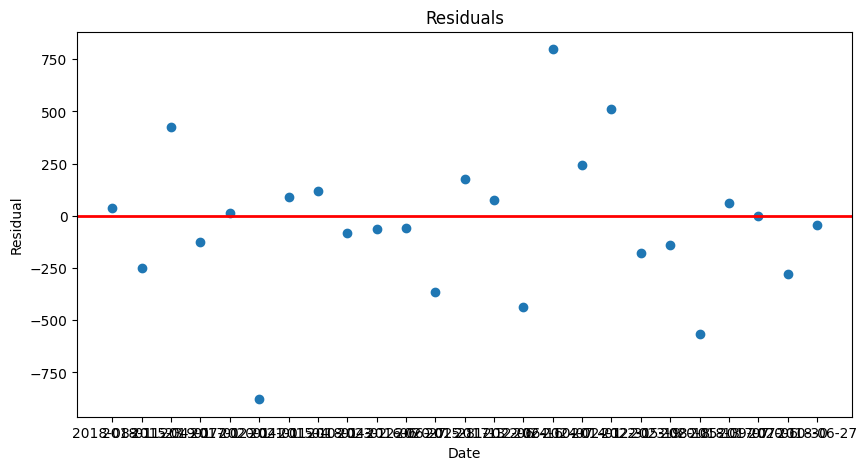

In [201]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


X_train, X_test, y_train, y_test = train_test_split(
    X_min, y_min, test_size=0.2, random_state=42
)

min_model = LinearRegression()
min_model.fit(X_train.loc[:, ["Date ordinal"]], y_train)

y_pred = min_model.predict(X_test.loc[:, ["Date ordinal"]])

plt.figure(figsize=(10, 5))
plt.plot(X["Date"], y, c="red", label="actual")
plt.plot(X_test["Date"], y_pred, c="green", label="predicted")
plt.legend()
plt.title("S&P500 Index")
plt.xlabel("Date")
plt.ylabel("S&P500 Index")
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
plt.scatter(X_test["Date"], residuals)
plt.axhline(0, color="red", lw=2)
plt.title("Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()